In [ ]:
from pathlib import Path

BASE = Path("eda.ipynb").parents[0].resolve()
DATA_PATH = BASE / "data" / "arxiv-metadata-oai-snapshot.json"

C:\Users\nguye\OneDrive\Documents\ANLP\ANLP-Citation-Recommendation\data\arxiv-metadata-oai-snapshot.json


In [24]:
import polars as pl
import json

data = json.load(open(DATA_PATH, "r", encoding="utf-8"))["root"]

rows = [
    {"paper_id": k, **v}
    for k, v in data.items()
]

df = pl.DataFrame(rows)

In [ ]:
df.describe

<bound method DataFrame.describe of shape: (16_695, 9)
┌────────────┬────────────┬────────────────┬────────────────┬───┬───────┬───────────┬──────┬───────┐
│ paper_id   ┆ id         ┆ authors        ┆ abstract       ┆ … ┆ venue ┆ venueType ┆ year ┆ month │
│ ---        ┆ ---        ┆ ---            ┆ ---            ┆   ┆ ---   ┆ ---       ┆ ---  ┆ ---   │
│ str        ┆ str        ┆ list[str]      ┆ str            ┆   ┆ str   ┆ str       ┆ i64  ┆ i64   │
╞════════════╪════════════╪════════════════╪════════════════╪═══╪═══════╪═══════════╪══════╪═══════╡
│ 2109.01288 ┆ 2109.01288 ┆ ["Zhao-Heng    ┆ We propose an  ┆ … ┆ ArXiv ┆           ┆ 2021 ┆ 9     │
│            ┆            ┆ Yin", "        ┆ imitation      ┆   ┆       ┆           ┆      ┆       │
│            ┆            ┆ Chenran Li…    ┆ lear…          ┆   ┆       ┆           ┆      ┆       │
│ 2111.09191 ┆ 2111.09191 ┆ ["Willem       ┆ We consider    ┆ … ┆ ArXiv ┆           ┆ 2021 ┆ 11    │
│            ┆            ┆ R\"opke"

In [42]:
df.null_count()

paper_id,id,authors,abstract,title,venue,venueType,year,month
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


In [41]:
df.n_unique()

16695

In [ ]:
from nltk.tokenize import word_tokenize

df = df.with_columns(
    pl.col("abstract")
    .map_elements(
        lambda x: len(word_tokenize(x)) if x is not None else 0,
        return_dtype=pl.Int64
    )
    .alias("abstract_token_count")
)

print(df["abstract_token_count"].describe())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nguye\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 16695.0    │
│ null_count ┆ 0.0        │
│ mean       ┆ 194.201497 │
│ std        ┆ 59.930771  │
│ min        ┆ 8.0        │
│ 25%        ┆ 154.0      │
│ 50%        ┆ 192.0      │
│ 75%        ┆ 232.0      │
│ max        ┆ 631.0      │
└────────────┴────────────┘


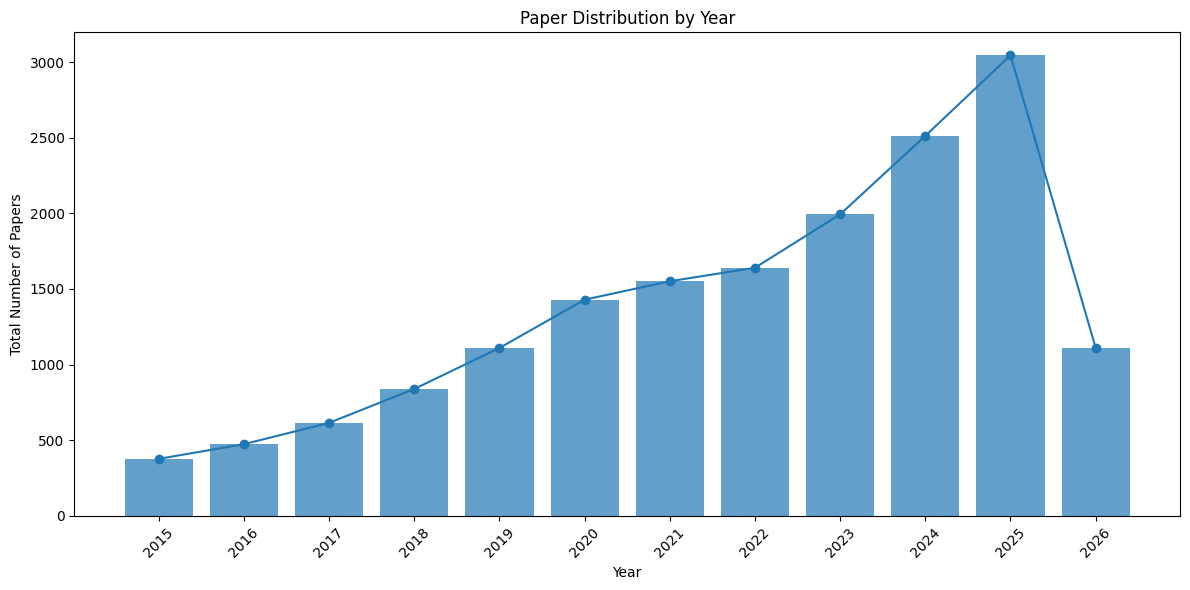

In [ ]:
import matplotlib.pyplot as plt

year_counts = (
    df.group_by("year")
    .len()
    .sort("year")
)

plot_df = year_counts.to_pandas()

plt.figure(figsize=(12, 6))

plt.bar(
    plot_df["year"],
    plot_df["len"],
    alpha=0.7
)

plt.plot(
    plot_df["year"],
    plot_df["len"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Total Number of Papers")
plt.title("Paper Distribution by Year")

plt.xticks(plot_df["year"], rotation=45)

plt.tight_layout()
plt.show()